In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/processed/battle_features.csv")
df.head()

,A_wins,strength_diff,speed_diff,intelligence_diff,strength_gap,speed_gap,intelligence_gap,strength_ratio,speed_ratio,intelligence_ratio,power_diff,total_diff,max_stat_diff,min_stat_diff,variance_diff,speed_advantage,speed_dominance
0,1,0,1,3,0,1,3,0.833333,1.000000,1.333333,1,4,1,0,1.666667,1,1.000000
1,1,-2,2,0,2,2,0,0.666667,1.142857,0.909091,0,0,0,0,0.000000,1,2.285714
2,0,-3,5,3,3,5,3,0.555556,1.800000,1.285714,2,5,1,1,1.333333,1,9.000000
3,0,0,-2,-5,0,2,5,0.888889,0.571429,0.454545,-2,-7,-2,-2,0.333333,0,-1.142857
4,0,2,-1,1,2,1,1,1.166667,0.750000,1.000000,1,2,0,1,-1.000000,0,-0.750000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   A_wins              300 non-null    int64  
 1   strength_diff       300 non-null    int64  
 2   speed_diff          300 non-null    int64  
 3   intelligence_diff   300 non-null    int64  
 4   strength_gap        300 non-null    int64  
 5   speed_gap           300 non-null    int64  
 6   intelligence_gap    300 non-null    int64  
 7   strength_ratio      300 non-null    float64
 8   speed_ratio         300 non-null    float64
 9   intelligence_ratio  300 non-null    float64
 10  power_diff          300 non-null    int64  
 11  total_diff          300 non-null    int64  
 12  max_stat_diff       300 non-null    int64  
 13  min_stat_diff       300 non-null    int64  
 14  variance_diff       300 non-null    float64
 15  speed_advantage     300 non-null    int64  
 16  speed_do

In [10]:
X = df.drop(columns = ["A_wins"])
y = df["A_wins"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state = 42, stratify = y)


In [12]:
rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = None,
     min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

accuracy, roc_auc

(0.4533333333333333, 0.4782763532763533)

In [14]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.44      0.47      0.45        36
           1       0.47      0.44      0.45        39

    accuracy                           0.45        75
   macro avg       0.45      0.45      0.45        75
weighted avg       0.45      0.45      0.45        75



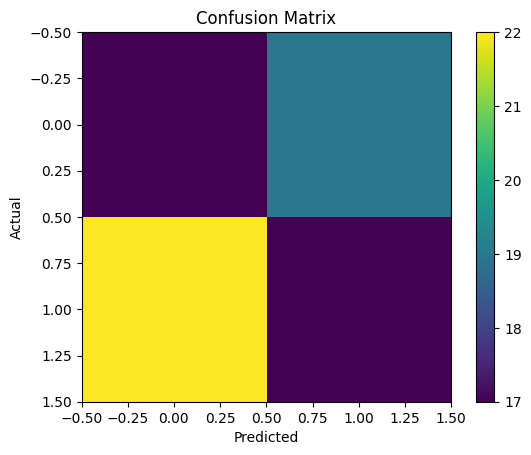

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [16]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

importances.head(10)


,feature,importance
13,variance_diff,0.132604
8,intelligence_ratio,0.092114
6,strength_ratio,0.081734
7,speed_ratio,0.079074
9,power_diff,0.074352
10,total_diff,0.073130
15,speed_dominance,0.063832
2,intelligence_diff,0.058829
5,intelligence_gap,0.053718
1,speed_diff,0.050458


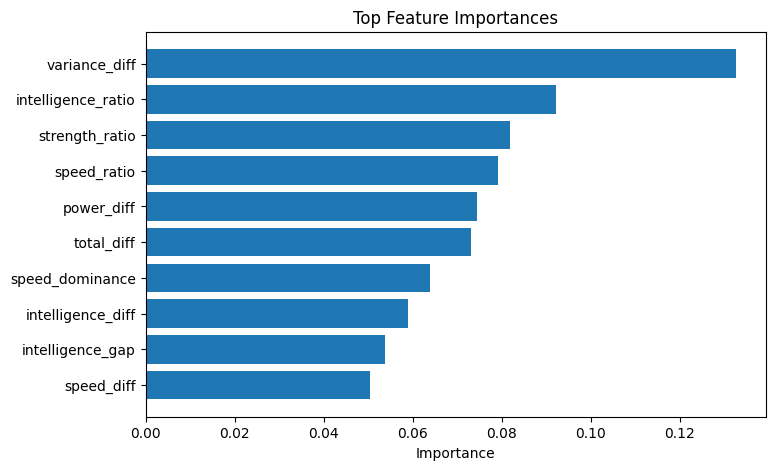

In [17]:
top_n = 10

plt.figure(figsize=(8, 5))
plt.barh(
    importances["feature"][:top_n][::-1],
    importances["importance"][:top_n][::-1]
)
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.show()


In [18]:
pd.Series(y_proba).describe()


count    75.000000
mean      0.522679
std       0.212583
min       0.020291
25%       0.365062
50%       0.470561
75%       0.682185
max       0.905984
dtype: float64

In [21]:
import joblib

joblib.dump(rf, "../model/battle_model.pkl")


['../model/battle_model.pkl']